In [1]:
import os
import sys
import shutil
import glob

# --- COLAB SETUP ---
try:
    from google.colab import drive
    IN_COLAB = True
    print("Running in Google Colab")

    drive.mount('/content/drive')

    REPO_URL = "https://github.com/zeynepoztunc/aml-procedural-mistake-detection.git"
    BRANCH = "emre-second-step"

    if not os.path.exists('/content/code'):
        !git clone --recursive {REPO_URL} /content/code
        os.chdir('/content/code')
        !git fetch origin {BRANCH}
        !git checkout {BRANCH}
    else:
        os.chdir('/content/code')
        !git fetch origin {BRANCH}
        !git checkout {BRANCH}
        !git pull origin {BRANCH}

    if '/content/code' not in sys.path:
        sys.path.append('/content/code')

    !pip install -q torcheval loguru scikit-learn

    # --- DATA SETUP ---
    DRIVE_BASE = "/content/drive/MyDrive/AML_Project"

    # Extract annotations from 1s.zip if needed
    data_zip = f"{DRIVE_BASE}/1s.zip"
    if not os.path.exists("annotations/annotation_json/step_annotations.json"):
        if os.path.exists(data_zip):
            print("Extracting annotations from 1s.zip...")
            !mkdir -p data
            !unzip -q -n "{data_zip}" -d data
            # Move annotations to expected location
            if os.path.exists("data/1s/annotations"):
                !cp -r data/1s/annotations .
            if os.path.exists("data/1s"):
                !rm -rf data/1s
            print("Annotations extracted.")

    # Copy step1 output from Drive if exists
    os.makedirs("extension_data", exist_ok=True)
    DRIVE_STEP1_OUTPUT = f"{DRIVE_BASE}/extension_data/step_embeddings_gt.pkl"
    LOCAL_STEP1_OUTPUT = "extension_data/step_embeddings_gt.pkl"

    if os.path.exists(DRIVE_STEP1_OUTPUT) and not os.path.exists(LOCAL_STEP1_OUTPUT):
        print("Copying step1 output from Drive...")
        !cp "{DRIVE_STEP1_OUTPUT}" "{LOCAL_STEP1_OUTPUT}"
        print("Done!")
    elif os.path.exists(LOCAL_STEP1_OUTPUT):
        print("Step1 output already exists locally.")
    else:
        print("WARNING: Step1 output not found. Run extension_step1 first!")

except ImportError:
    IN_COLAB = False
    print("Not running in Colab")

Running in Google Colab
Mounted at /content/drive
Cloning into '/content/code'...
remote: Enumerating objects: 478, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 478 (delta 27), reused 28 (delta 17), pack-reused 430 (from 2)
Receiving objects: 100% (478/478), 134.63 KiB | 1.13 MiB/s, done.
Resolving deltas: 100% (308/308), done.
Submodule 'annotations' (https://github.com/CaptainCook4D/annotations) registered for path 'annotations'
Cloning into '/content/code/annotations'...
remote: Enumerating objects: 152, done.        
remote: Counting objects: 100% (152/152), done.        
remote: Compressing objects: 100% (98/98), done.        
remote: Total 152 (delta 75), reused 108 (delta 46), pack-reused 0 (from 0)        
Receiving objects: 100% (152/152), 793.14 KiB | 3.24 MiB/s, done.
Resolving deltas: 100% (75/75), done.
Submodule path 'annotations': checked out '0e9a108be2cbcbcbd592e7418c0ab9c16232d27a'
From https://gith

In [2]:
import pickle
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from collections import defaultdict
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 1. Load Processed Data from Substep 1

In [3]:
# Load data from Substep 1
DATA_PATH = "extension_data/step_embeddings_gt.pkl"

if IN_COLAB:
    DRIVE_DATA_PATH = "/content/drive/MyDrive/AML_Project/extension_data/step_embeddings_gt.pkl"
    if os.path.exists(DRIVE_DATA_PATH):
        DATA_PATH = DRIVE_DATA_PATH

if os.path.exists(DATA_PATH):
    with open(DATA_PATH, 'rb') as f:
        loaded_data = pickle.load(f)

    processed_data = loaded_data['data']
    splits = loaded_data['splits']
    print(f"Loaded {len(processed_data)} recordings")
else:
    print(f"Data not found at {DATA_PATH}")
    print("Please run extension_step1_localization.ipynb first!")

Loaded 383 recordings


In [4]:
# Get feature dimension from data
sample_key = list(processed_data.keys())[0]
FEATURE_DIM = processed_data[sample_key]['step_embeddings'].shape[1]
print(f"Feature dimension: {FEATURE_DIM}")

# Group recordings by recipe type
recipe_groups = defaultdict(list)
for recording_id, data in processed_data.items():
    recipe_id = data['recipe_id']
    recipe_groups[recipe_id].append(recording_id)

print(f"\nNumber of unique recipes: {len(recipe_groups)}")
for recipe_id, recordings in list(recipe_groups.items())[:5]:
    labels = [processed_data[r]['recipe_label'] for r in recordings]
    print(f"  Recipe {recipe_id}: {len(recordings)} recordings ({sum(labels)} with errors)")

Feature dimension: 256

Number of unique recipes: 24
  Recipe 1: 18 recordings (13 with errors)
  Recipe 10: 12 recordings (8 with errors)
  Recipe 12: 17 recordings (6 with errors)
  Recipe 13: 14 recordings (9 with errors)
  Recipe 15: 15 recordings (10 with errors)


## 2. Define Dataset and Models

In [5]:
class TaskVerificationDataset(Dataset):
    """
    Dataset for Task Verification.
    Each sample is a sequence of step embeddings with a recipe-level label.
    """
    def __init__(self, recording_ids, processed_data, max_steps=50):
        self.recording_ids = recording_ids
        self.processed_data = processed_data
        self.max_steps = max_steps

    def __len__(self):
        return len(self.recording_ids)

    def __getitem__(self, idx):
        recording_id = self.recording_ids[idx]
        data = self.processed_data[recording_id]

        step_emb = data['step_embeddings']  # (num_steps, feature_dim)
        label = data['recipe_label']

        # Pad or truncate to max_steps
        num_steps = step_emb.shape[0]
        feature_dim = step_emb.shape[1]

        if num_steps > self.max_steps:
            step_emb = step_emb[:self.max_steps]
            mask = np.ones(self.max_steps)
        else:
            padded = np.zeros((self.max_steps, feature_dim))
            padded[:num_steps] = step_emb
            step_emb = padded
            mask = np.zeros(self.max_steps)
            mask[:num_steps] = 1

        return {
            'embeddings': torch.FloatTensor(step_emb),
            'mask': torch.FloatTensor(mask),
            'label': torch.FloatTensor([label]),
            'num_steps': num_steps
        }


def collate_fn(batch):
    return {
        'embeddings': torch.stack([x['embeddings'] for x in batch]),
        'mask': torch.stack([x['mask'] for x in batch]),
        'label': torch.stack([x['label'] for x in batch]),
        'num_steps': [x['num_steps'] for x in batch]
    }

In [6]:
class MLPTaskVerifier(nn.Module):
    """MLP baseline: Pool step embeddings then classify."""

    def __init__(self, feature_dim, hidden_dim=256, dropout=0.3):
        super().__init__()
        self.fc1 = nn.Linear(feature_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc3 = nn.Linear(hidden_dim // 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(hidden_dim)

    def forward(self, embeddings, mask):
        # embeddings: (batch, max_steps, feature_dim)
        # mask: (batch, max_steps)

        # Masked mean pooling
        mask_expanded = mask.unsqueeze(-1)  # (batch, max_steps, 1)
        masked_emb = embeddings * mask_expanded
        pooled = masked_emb.sum(dim=1) / mask.sum(dim=1, keepdim=True).clamp(min=1)

        # MLP
        x = F.relu(self.layer_norm(self.fc1(pooled)))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)

        return x


class TransformerTaskVerifier(nn.Module):
    """Transformer baseline for task verification."""

    def __init__(self, feature_dim, hidden_dim=256, num_heads=4, num_layers=2, dropout=0.3, max_steps=50):
        super().__init__()

        # Projection
        self.input_proj = nn.Linear(feature_dim, hidden_dim)

        # Positional encoding
        self.pos_encoding = nn.Parameter(torch.randn(1, max_steps, hidden_dim) * 0.02)

        # CLS token for classification
        self.cls_token = nn.Parameter(torch.randn(1, 1, hidden_dim) * 0.02)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim * 4,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, embeddings, mask):
        batch_size = embeddings.shape[0]

        # Project input
        x = self.input_proj(embeddings)  # (batch, max_steps, hidden_dim)

        # Add positional encoding
        x = x + self.pos_encoding[:, :x.shape[1], :]

        # Prepend CLS token
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)

        # Update mask for CLS token
        cls_mask = torch.ones(batch_size, 1, device=mask.device)
        full_mask = torch.cat([cls_mask, mask], dim=1)

        # Create attention mask (True = ignore)
        attn_mask = (full_mask == 0)

        # Transformer forward
        x = self.transformer(x, src_key_padding_mask=attn_mask)

        # Use CLS token for classification
        cls_output = x[:, 0, :]

        return self.classifier(cls_output)


class LSTMTaskVerifier(nn.Module):
    """LSTM baseline for task verification."""

    def __init__(self, feature_dim, hidden_dim=256, num_layers=2, dropout=0.3):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=feature_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, embeddings, mask):
        # Pack padded sequence for efficient LSTM
        lengths = mask.sum(dim=1).long()
        lengths = lengths.clamp(min=1)  # Avoid zero lengths

        # Sort by length for packing
        sorted_lengths, sort_idx = lengths.sort(descending=True)
        sorted_emb = embeddings[sort_idx]

        # Pack
        packed = nn.utils.rnn.pack_padded_sequence(
            sorted_emb, sorted_lengths.cpu(), batch_first=True, enforce_sorted=True
        )

        # LSTM forward
        _, (h_n, _) = self.lstm(packed)

        # Concatenate forward and backward hidden states
        hidden = torch.cat([h_n[-2], h_n[-1]], dim=-1)

        # Unsort
        _, unsort_idx = sort_idx.sort()
        hidden = hidden[unsort_idx]

        return self.classifier(hidden)

## 3. Training Functions

In [7]:
def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in dataloader:
        embeddings = batch['embeddings'].to(device)
        mask = batch['mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(embeddings, mask)
        loss = criterion(outputs, labels)
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()

        preds = torch.sigmoid(outputs).detach().cpu().numpy()
        all_preds.extend(preds.flatten())
        all_labels.extend(labels.cpu().numpy().flatten())

    return total_loss / len(dataloader), np.array(all_preds), np.array(all_labels)


def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            embeddings = batch['embeddings'].to(device)
            mask = batch['mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(embeddings, mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = torch.sigmoid(outputs).cpu().numpy()
            all_preds.extend(preds.flatten())
            all_labels.extend(labels.cpu().numpy().flatten())

    return total_loss / len(dataloader), np.array(all_preds), np.array(all_labels)


def compute_metrics(preds, labels, threshold=0.5):
    binary_preds = (preds >= threshold).astype(int)

    metrics = {
        'accuracy': accuracy_score(labels, binary_preds),
        'precision': precision_score(labels, binary_preds, zero_division=0),
        'recall': recall_score(labels, binary_preds, zero_division=0),
        'f1': f1_score(labels, binary_preds, zero_division=0),
    }

    try:
        metrics['auc'] = roc_auc_score(labels, preds)
    except:
        metrics['auc'] = 0.5

    return metrics

## 4. Leave-One-Recipe-Out Evaluation

In [8]:
def leave_one_recipe_out_eval(model_class, processed_data, recipe_groups,
                               feature_dim, num_epochs=20, lr=1e-3,
                               batch_size=16, pos_weight=2.0, **model_kwargs):
    """
    Leave-one-recipe-out cross-validation.
    Train on (k-1) recipes, test on k-th recipe.
    """
    recipe_ids = list(recipe_groups.keys())
    all_results = []

    print(f"\nRunning Leave-One-Recipe-Out evaluation with {len(recipe_ids)} folds")

    for fold_idx, test_recipe in enumerate(tqdm(recipe_ids, desc="Folds")):
        # Split data
        train_ids = []
        test_ids = recipe_groups[test_recipe]

        for recipe, recordings in recipe_groups.items():
            if recipe != test_recipe:
                train_ids.extend(recordings)

        if len(test_ids) < 2 or len(train_ids) < 10:
            continue

        # Create datasets
        train_dataset = TaskVerificationDataset(train_ids, processed_data)
        test_dataset = TaskVerificationDataset(test_ids, processed_data)

        train_loader = DataLoader(train_dataset, batch_size=batch_size,
                                  shuffle=True, collate_fn=collate_fn)
        test_loader = DataLoader(test_dataset, batch_size=batch_size,
                                 shuffle=False, collate_fn=collate_fn)

        # Initialize model
        model = model_class(feature_dim, **model_kwargs).to(device)

        # Loss with positive class weighting
        criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(device))
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

        # Training
        best_val_loss = float('inf')
        best_model_state = None

        for epoch in range(num_epochs):
            train_loss, _, _ = train_epoch(model, train_loader, optimizer, criterion, device)
            scheduler.step()

            # Simple early stopping based on training loss
            if train_loss < best_val_loss:
                best_val_loss = train_loss
                best_model_state = model.state_dict().copy()

        # Load best model
        if best_model_state:
            model.load_state_dict(best_model_state)

        # Evaluate on test fold
        test_loss, test_preds, test_labels = evaluate(model, test_loader, criterion, device)
        metrics = compute_metrics(test_preds, test_labels)

        all_results.append({
            'fold': fold_idx,
            'test_recipe': test_recipe,
            'train_size': len(train_ids),
            'test_size': len(test_ids),
            **metrics
        })

    return all_results


def summarize_results(results, model_name):
    """Aggregate results across folds."""
    metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc']

    print(f"\n{'='*60}")
    print(f"{model_name} Results (Leave-One-Recipe-Out)")
    print(f"{'='*60}")

    for metric in metrics:
        values = [r[metric] for r in results]
        print(f"{metric.capitalize():12s}: {np.mean(values)*100:.2f}% ± {np.std(values)*100:.2f}%")

    print(f"{'='*60}")

    return {
        metric: {'mean': np.mean([r[metric] for r in results]),
                 'std': np.std([r[metric] for r in results])}
        for metric in metrics
    }

## 5. Train and Evaluate All Models

In [9]:
# Hyperparameters
NUM_EPOCHS = 30
LEARNING_RATE = 5e-4
BATCH_SIZE = 16
POS_WEIGHT = 2.0  # Weight for positive class (incorrect recipes)
HIDDEN_DIM = 256

all_model_results = {}

In [10]:
# MLP Baseline
print("\n" + "="*60)
print("Training MLP Baseline")
print("="*60)

mlp_results = leave_one_recipe_out_eval(
    MLPTaskVerifier,
    processed_data,
    recipe_groups,
    feature_dim=FEATURE_DIM,
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    pos_weight=POS_WEIGHT,
    hidden_dim=HIDDEN_DIM
)

all_model_results['MLP'] = summarize_results(mlp_results, "MLP Baseline")


Training MLP Baseline

Running Leave-One-Recipe-Out evaluation with 24 folds


Folds: 100%|██████████| 24/24 [01:23<00:00,  3.48s/it]


MLP Baseline Results (Leave-One-Recipe-Out)
Accuracy    : 59.36% ± 13.31%
Precision   : 64.17% ± 16.74%
Recall      : 68.72% ± 23.89%
F1          : 63.18% ± 16.91%
Auc         : 68.05% ± 12.59%


In [11]:
# Transformer Baseline
print("\n" + "="*60)
print("Training Transformer Baseline")
print("="*60)

transformer_results = leave_one_recipe_out_eval(
    TransformerTaskVerifier,
    processed_data,
    recipe_groups,
    feature_dim=FEATURE_DIM,
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    pos_weight=POS_WEIGHT,
    hidden_dim=HIDDEN_DIM,
    num_heads=4,
    num_layers=2
)

all_model_results['Transformer'] = summarize_results(transformer_results, "Transformer Baseline")


Training Transformer Baseline

Running Leave-One-Recipe-Out evaluation with 24 folds


Folds: 100%|██████████| 24/24 [02:37<00:00,  6.55s/it]


Transformer Baseline Results (Leave-One-Recipe-Out)
Accuracy    : 66.09% ± 14.96%
Precision   : 70.99% ± 17.15%
Recall      : 67.14% ± 23.36%
F1          : 66.85% ± 19.63%
Auc         : 68.37% ± 14.55%


In [12]:
# LSTM Baseline
print("\n" + "="*60)
print("Training LSTM Baseline")
print("="*60)

lstm_results = leave_one_recipe_out_eval(
    LSTMTaskVerifier,
    processed_data,
    recipe_groups,
    feature_dim=FEATURE_DIM,
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    pos_weight=POS_WEIGHT,
    hidden_dim=HIDDEN_DIM,
    num_layers=2
)

all_model_results['LSTM'] = summarize_results(lstm_results, "LSTM Baseline")


Training LSTM Baseline

Running Leave-One-Recipe-Out evaluation with 24 folds


Folds: 100%|██████████| 24/24 [02:53<00:00,  7.23s/it]


LSTM Baseline Results (Leave-One-Recipe-Out)
Accuracy    : 60.87% ± 12.93%
Precision   : 64.85% ± 15.76%
Recall      : 73.74% ± 20.42%
F1          : 66.34% ± 15.31%
Auc         : 68.38% ± 14.54%


## 6. Results Comparison

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Create comparison table
comparison_data = []
for model_name, results in all_model_results.items():
    row = {'Model': model_name}
    for metric, values in results.items():
        row[f'{metric.capitalize()}'] = f"{values['mean']*100:.1f}%"
    comparison_data.append(row)

df = pd.DataFrame(comparison_data)
print("\nModel Comparison (Leave-One-Recipe-Out):")
print(df.to_string(index=False))


Model Comparison (Leave-One-Recipe-Out):
      Model Accuracy Precision Recall    F1   Auc
        MLP    59.4%     64.2%  68.7% 63.2% 68.1%
Transformer    66.1%     71.0%  67.1% 66.9% 68.4%
       LSTM    60.9%     64.9%  73.7% 66.3% 68.4%


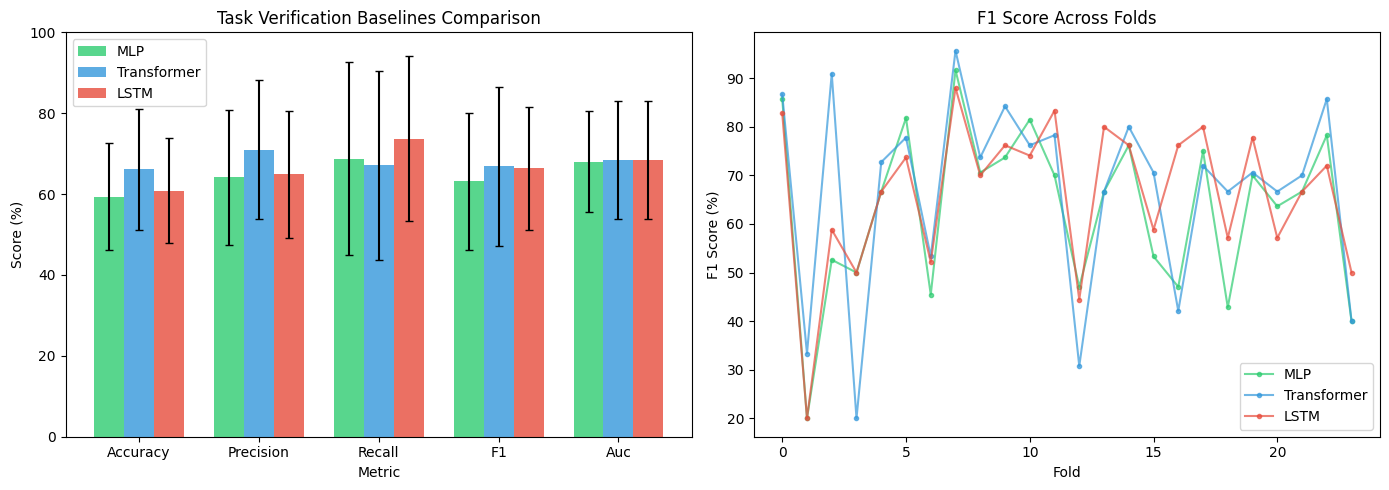

In [14]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart comparison
metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc']
x = np.arange(len(metrics))
width = 0.25

colors = ['#2ecc71', '#3498db', '#e74c3c']
for i, (model_name, results) in enumerate(all_model_results.items()):
    means = [results[m]['mean'] * 100 for m in metrics]
    stds = [results[m]['std'] * 100 for m in metrics]
    axes[0].bar(x + i*width, means, width, yerr=stds, label=model_name,
                color=colors[i], alpha=0.8, capsize=3)

axes[0].set_xlabel('Metric')
axes[0].set_ylabel('Score (%)')
axes[0].set_title('Task Verification Baselines Comparison')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels([m.capitalize() for m in metrics])
axes[0].legend()
axes[0].set_ylim(0, 100)

# F1 Score across folds
for model_name, results_list, color in zip(
    ['MLP', 'Transformer', 'LSTM'],
    [mlp_results, transformer_results, lstm_results],
    colors
):
    f1_scores = [r['f1'] * 100 for r in results_list]
    axes[1].plot(f1_scores, label=model_name, color=color, alpha=0.7, marker='o', markersize=3)

axes[1].set_xlabel('Fold')
axes[1].set_ylabel('F1 Score (%)')
axes[1].set_title('F1 Score Across Folds')
axes[1].legend()

plt.tight_layout()
plt.savefig('extension_data/task_verification_baselines.png', dpi=150)
plt.show()

In [15]:
# Save results
import json

results_to_save = {
    'summary': all_model_results,
    'mlp_folds': mlp_results,
    'transformer_folds': transformer_results,
    'lstm_folds': lstm_results,
    'config': {
        'num_epochs': NUM_EPOCHS,
        'learning_rate': LEARNING_RATE,
        'batch_size': BATCH_SIZE,
        'pos_weight': POS_WEIGHT,
        'hidden_dim': HIDDEN_DIM,
        'feature_dim': FEATURE_DIM
    }
}

# Convert numpy types for JSON serialization
def convert_numpy(obj):
    if isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, dict):
        return {k: convert_numpy(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_numpy(i) for i in obj]
    return obj

with open('extension_data/task_verification_results.json', 'w') as f:
    json.dump(convert_numpy(results_to_save), f, indent=2)

print("Results saved to extension_data/task_verification_results.json")

Results saved to extension_data/task_verification_results.json


## Summary

In this notebook, we completed **Substep 2: Task Verification Baselines**:

1. ✅ Loaded step-level embeddings from Substep 1
2. ✅ Implemented 3 baseline models:
   - MLP: Pool + feedforward
   - Transformer: Self-attention + CLS token
   - LSTM: Bidirectional sequence modeling
3. ✅ Trained with Leave-One-Recipe-Out cross-validation
4. ✅ Compared models on Accuracy, Precision, Recall, F1, AUC

**Key Observations**:
- These baselines use ONLY visual features (no task graph information)
- Performance is limited without structural knowledge from task graphs

**Next**: Proceed to **Substep 3** - Task-Graph Encoding + Step Matching

This will incorporate the task graph structure using EgoVLP text encoder for node embeddings and Hungarian matching to align visual steps with graph nodes.